#AN2DL
**Second Challenge**

*Marcus.ai*

###Loading Cleaned Data

In [ ]:
import os
import re
import random
import warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models import (
    resnet50, ResNet50_Weights,
    resnet101, ResNet101_Weights
)

np.random.seed(42)
random.seed(42)


In [ ]:
!cp /content/drive/MyDrive/AN2DL/bbox_data_cleaned.zip bbox_data_cleaned.zip
!unzip bbox_data_cleaned.zip

Streaming output truncated to the last 5000 lines.
  inflating: train_tiles_filtered/img_0146_tile_03.png  
  inflating: train_tiles_filtered/img_0146_tile_04.png  
  inflating: train_tiles_filtered/img_0147_tile_01.png  
  inflating: train_tiles_filtered/img_0147_tile_02.png  
  inflating: train_tiles_filtered/img_0149_tile_01.png  
  inflating: train_tiles_filtered/img_0149_tile_02.png  
  inflating: train_tiles_filtered/img_0150_tile_01.png  
  inflating: train_tiles_filtered/img_0150_tile_02.png  
  inflating: train_tiles_filtered/img_0150_tile_03.png  
  inflating: train_tiles_filtered/img_0150_tile_04.png  
  inflating: train_tiles_filtered/img_0150_tile_05.png  
  inflating: train_tiles_filtered/img_0151_tile_01.png  
  inflating: train_tiles_filtered/img_0151_tile_02.png  
  inflating: train_tiles_filtered/img_0151_tile_03.png  
  inflating: train_tiles_filtered/img_0151_tile_04.png  
  inflating: train_tiles_filtered/img_0151_tile_05.png  
  inflating: train_tiles_filtered/img

In [ ]:
# Load train_labels.csv
labels_df = pd.read_csv("train_labels.csv")
# The sample_index in the CSV is already a string like 'img_0000.png'.
# We need to remove the '.png' extension to match the image IDs extracted from tile filenames.
labels_df['sample_index'] = labels_df['sample_index'].str.replace('.png', '', regex=False)
labels_df = labels_df.set_index('sample_index')
print(f"Loaded {len(labels_df)} labels from train_labels.csv")

# Initialize empty lists
X_train_loaded = []
y_train_loaded = []
img_indices_train_loaded = []

# Directory containing image tiles
tile_dir = "/content/train_tiles_filtered"
image_size = (224, 224) # Target size for resizing

# Iterate through all files in the directory
all_files = os.listdir(tile_dir)
image_tile_files = [f for f in all_files if f.startswith('img_') and f.endswith('.png') and 'mask' not in f]

print(f"Found {len(image_tile_files)} image tiles to process.")

# Use tqdm for a progress bar
for filename in tqdm(image_tile_files, desc="Processing image tiles"):
    filepath = os.path.join(tile_dir, filename)

    # Extract the main image ID (e.g., img_XXXX) from the tile filename
    match = re.match(r"^(img_\d{4})_tile_\d{2}\.png$", filename)
    if match:
        main_image_id = match.group(1)

        # Use the main image ID to look up the corresponding label
        if main_image_id in labels_df.index:
            label = labels_df.loc[main_image_id, 'label']

            # Load the image tile, resize, convert to NumPy array, and transpose
            try:
                img = Image.open(filepath).convert('RGB')
                if img.size != image_size:
                    img = img.resize(image_size)

                img_array = np.array(img, dtype=np.uint8) # Keep as uint8 for now, normalize later in Dataset
                img_array = img_array.transpose(2, 0, 1) # Convert to (channels, height, width)

                # Append the processed image array, the label, and the main image ID
                X_train_loaded.append(img_array)
                y_train_loaded.append(label)
                img_indices_train_loaded.append(main_image_id)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
        else:
            # print(f"Warning: Label not found for image ID {main_image_id} (tile: {filename})")
            pass # Skip tiles without a corresponding label
    else:
        # print(f"Warning: Filename {filename} does not match expected pattern.")
        pass # Skip files that don't match the tile pattern

# Convert these lists into NumPy arrays
X_train_loaded = np.array(X_train_loaded)
y_train_loaded = np.array(y_train_loaded)
img_indices_train_loaded = np.array(img_indices_train_loaded)

print(f"\nFinished loading data.")
print(f"X_train_loaded shape: {X_train_loaded.shape}")
print(f"y_train_loaded shape: {y_train_loaded.shape}")
print(f"img_indices_train_loaded shape: {img_indices_train_loaded.shape}")

Loaded 631 labels from train_labels.csv
Found 2776 image tiles to process.


Processing image tiles:   0%|          | 0/2776 [00:00<?, ?it/s]


Finished loading data.
X_train_loaded shape: (2776, 3, 224, 224)
y_train_loaded shape: (2776,)
img_indices_train_loaded shape: (2776,)


###Training First Model (Resnet101)

Train patches: (2219, 3, 224, 224) Val patches: (557, 3, 224, 224)
Train unique images: 504 Val unique images: 127
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 136MB/s]


Epoch 01/30 [FROZEN] | train_loss=1.3770 | val_patch_loss=1.3282 | val_img_macro_f1=0.3490 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
  ✅ best image-level F1 improved
Epoch 02/30 [FROZEN] | train_loss=1.3203 | val_patch_loss=1.3413 | val_img_macro_f1=0.2942 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
Epoch 03/30 [FROZEN] | train_loss=1.2722 | val_patch_loss=1.3375 | val_img_macro_f1=0.3009 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
Epoch 04/30 [FROZEN] | train_loss=1.2504 | val_patch_loss=1.3156 | val_img_macro_f1=0.3351 (imgs=127) | lr_backbone=1.50e-05 lr_head=1.50e-04
Epoch 05/30 [FROZEN] | train_loss=1.2222 | val_patch_loss=1.2963 | val_img_macro_f1=0.4180 (imgs=127) | lr_backbone=1.50e-05 lr_head=1.50e-04
  ✅ best image-level F1 improved

🔓 Unfreezing layer4 at epoch 6 (layer4 + head trainable)
Epoch 06/30 [L4+HEAD] | train_loss=1.1938 | val_patch_loss=1.3212 | val_img_macro_f1=0.3664 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
Epoch 07/30 [L4+HEAD] |

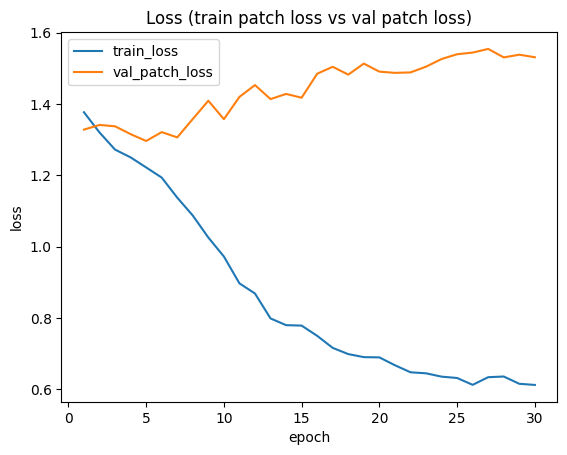

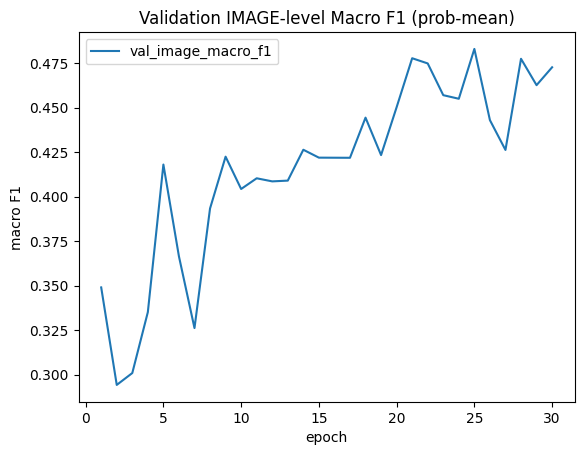

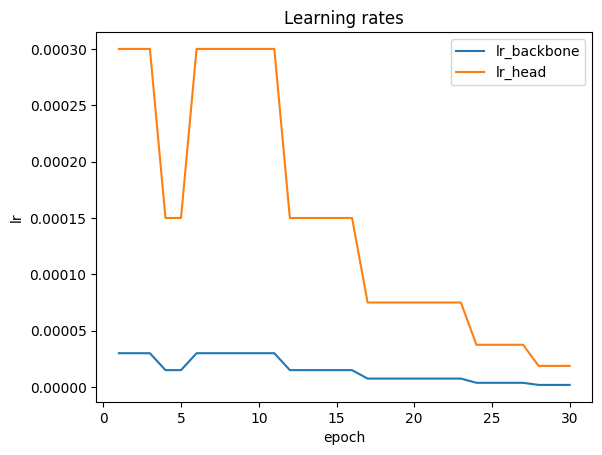

In [ ]:
# No-fold training: patch training + IMAGE-level validation (probability aggregation)
# Regularized head (2048->256->4 + dropout), label smoothing, freeze backbone 5 epochs then unfreeze layer4
# Plots: train loss, val image-F1, val image-loss

# CONFIG
SEED = 42
FREEZE_EPOCHS = 5
EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 2

HEAD_LR = 3e-4
BACKBONE_LR = 3e-5
WEIGHT_DECAY = 1e-4

DROPOUT_P = 0.4
HIDDEN = 256
LABEL_SMOOTHING = 0.05

AUG_P_FLIP = 0.5
AUG_MAX_SHIFT = 8


LABEL2ID = {"HER2(+)": 0, "Luminal A": 1, "Luminal B": 2, "Triple negative": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def encode_labels(y):
    y = np.asarray(y)
    if y.dtype == object or y.dtype.type is np.str_:
        y = np.vectorize(LABEL2ID.get)(y)
    return y.astype(np.int64)

def seed_all(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)


# AUGMENT
class SimpleAug:
    def __init__(self, p_flip=0.5, max_shift=8):
        self.p_flip = p_flip
        self.max_shift = max_shift

    def __call__(self, x):  # x: (C,H,W)
        if torch.rand(1).item() < self.p_flip:
            x = TF.hflip(x)
        if torch.rand(1).item() < self.p_flip:
            x = TF.vflip(x)
        if self.max_shift > 0:
            dx = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
            dy = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
            x = TF.affine(
                x, angle=0.0, translate=[dx, dy], scale=1.0, shear=[0.0, 0.0],
                interpolation=TF.InterpolationMode.BILINEAR
            )
        return x


# DATASET (returns patch + label + img_id)
class PatchDataset(Dataset):
    def __init__(self, X, y, img_ids, augment=None):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(encode_labels(y)).long()
        self.img_ids = np.asarray(img_ids)  # keep as numpy (strings ok)
        self.augment = augment

        if self.X.max() > 1.5:  # 0..255 -> 0..1
            self.X = self.X / 255.0

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self): return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3,224,224) in [0,1]
        y = self.y[idx]
        img_id = self.img_ids[idx]

        if self.augment is not None:
            x = self.augment(x)

        x = (x - self.mean) / self.std
        return x, y, img_id


# MODEL: ResNet101 + regularized head
def build_model():
    m = resnet101(weights=ResNet101_Weights.DEFAULT)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, HIDDEN),
        nn.ReLU(inplace=True),
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(HIDDEN, 4),
    )
    return m

def freeze_backbone(model, freeze=True):
    for name, p in model.named_parameters():
        if name.startswith("fc."):
            p.requires_grad = True
        else:
            p.requires_grad = not freeze

def unfreeze_layer4_only(model):
    # keep everything frozen except layer4 + fc
    for name, p in model.named_parameters():
        if name.startswith("fc.") or name.startswith("layer4."):
            p.requires_grad = True
        else:
            p.requires_grad = False

def make_optimizer(model, head_lr, backbone_lr, wd):
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("fc."):
            head_params.append(p)
        else:
            backbone_params.append(p)
    return torch.optim.AdamW(
        [{"params": backbone_params, "lr": backbone_lr},
         {"params": head_params, "lr": head_lr}],
        weight_decay=wd
    )

# IMAGE-LEVEL VALIDATION (mean probability aggregation)
@torch.no_grad()
def eval_image_level(model, loader, device, criterion):
    model.eval()

    # accumulate per-image probability sums and counts
    prob_sum = {}   # img_id -> np.array(4,)
    count = {}      # img_id -> int
    true_label = {} # img_id -> int

    loss_sum, n = 0.0, 0

    for xb, yb, img_id in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        probs = F.softmax(logits, dim=1).detach().cpu().numpy()
        y_cpu = yb.detach().cpu().numpy()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        n += bs

        # img_id is a tuple/list of strings/ints from DataLoader
        for i in range(bs):
            k = img_id[i]
            if k not in prob_sum:
                prob_sum[k] = probs[i].copy()
                count[k] = 1
                true_label[k] = int(y_cpu[i])
            else:
                prob_sum[k] += probs[i]
                count[k] += 1

    # finalize per image
    y_true, y_pred = [], []
    for k in prob_sum.keys():
        mean_probs = prob_sum[k] / count[k]
        pred = int(mean_probs.argmax())
        y_true.append(true_label[k])
        y_pred.append(pred)

    img_macro_f1 = f1_score(y_true, y_pred, average="macro") if len(y_true) else 0.0
    patch_loss = loss_sum / max(n, 1)

    return patch_loss, img_macro_f1, len(y_true)

class EarlyStopF1:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -1.0
        self.bad = 0

    def step(self, f1):
        if f1 > self.best + self.min_delta:
            self.best = f1
            self.bad = 0
            return True
        self.bad += 1
        return False

    @property
    def stop(self):
        return self.bad >= self.patience


# SPLIT BY IMAGE
y_all = encode_labels(y_train_loaded)
img_ids_all = np.asarray(img_indices_train_loaded)

unique_imgs = np.unique(img_ids_all)
train_imgs, val_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=SEED, shuffle=True)

train_mask = np.isin(img_ids_all, train_imgs)
val_mask = np.isin(img_ids_all, val_imgs)

X_tr, y_tr, ids_tr = X_train_loaded[train_mask], y_train_loaded[train_mask], img_ids_all[train_mask]
X_va, y_va, ids_va = X_train_loaded[val_mask],   y_train_loaded[val_mask],   img_ids_all[val_mask]

print("Train patches:", X_tr.shape, "Val patches:", X_va.shape)
print("Train unique images:", len(np.unique(ids_tr)), "Val unique images:", len(np.unique(ids_va)))


# DATALOADERS
aug = SimpleAug(p_flip=AUG_P_FLIP, max_shift=AUG_MAX_SHIFT)
train_ds = PatchDataset(X_tr, y_tr, ids_tr, augment=aug)
val_ds   = PatchDataset(X_va, y_va, ids_va, augment=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)


# LOSS (class weights + label smoothing)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_model().to(device)

ytr_int = torch.from_numpy(encode_labels(y_tr))
counts = np.bincount(ytr_int.numpy(), minlength=4).astype(np.float32)
cw = counts.sum() / (counts + 1e-8)
cw = cw / cw.mean()
class_w = torch.tensor(cw, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=LABEL_SMOOTHING)


# TRAIN LOOP
hist = {"train_loss": [], "val_patch_loss": [], "val_img_f1": [], "lr_head": [], "lr_backbone": []}
early = EarlyStopF1(patience=6)

best_state = None

# freeze backbone for first FREEZE_EPOCHS
freeze_backbone(model, freeze=True)
optimizer = make_optimizer(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, wd=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

for epoch in range(1, EPOCHS + 1):
    # unfreeze at epoch FREEZE_EPOCHS+1 (only layer4 + head)
    if epoch == FREEZE_EPOCHS + 1:
        print(f"\n🔓 Unfreezing layer4 at epoch {epoch} (layer4 + head trainable)")
        unfreeze_layer4_only(model)
        optimizer = make_optimizer(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, wd=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    model.train()
    loss_sum, n = 0.0, 0

    for xb, yb, _ in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        n += bs

    train_loss = loss_sum / max(n, 1)

    val_patch_loss, val_img_f1, n_val_imgs = eval_image_level(model, val_loader, device, criterion)
    scheduler.step(val_img_f1)

    # track LRs
    lr_backbone = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    hist["train_loss"].append(train_loss)
    hist["val_patch_loss"].append(val_patch_loss)
    hist["val_img_f1"].append(val_img_f1)
    hist["lr_head"].append(lr_head)
    hist["lr_backbone"].append(lr_backbone)

    phase = "FROZEN" if epoch <= FREEZE_EPOCHS else "L4+HEAD"
    print(f"Epoch {epoch:02d}/{EPOCHS} [{phase}] | "
          f"train_loss={train_loss:.4f} | val_patch_loss={val_patch_loss:.4f} | "
          f"val_img_macro_f1={val_img_f1:.4f} (imgs={n_val_imgs}) | "
          f"lr_backbone={lr_backbone:.2e} lr_head={lr_head:.2e}")

    if early.step(val_img_f1):
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print("  ✅ best image-level F1 improved")
    if early.stop:
        print(f"🛑 early stop. best val_img_macro_f1={early.best:.4f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

# save
torch.save(model.state_dict(), "best_resnet101_imageval.pth")
print("✅ Saved best model to best_resnet101_imageval.pth")


# PLOTS
xs = np.arange(1, len(hist["train_loss"]) + 1)

plt.figure()
plt.plot(xs, hist["train_loss"], label="train_loss")
plt.plot(xs, hist["val_patch_loss"], label="val_patch_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss (train patch loss vs val patch loss)")
plt.show()

plt.figure()
plt.plot(xs, hist["val_img_f1"], label="val_image_macro_f1")
plt.xlabel("epoch"); plt.ylabel("macro F1"); plt.legend(); plt.title("Validation IMAGE-level Macro F1 (prob-mean)")
plt.show()

plt.figure()
plt.plot(xs, hist["lr_backbone"], label="lr_backbone")
plt.plot(xs, hist["lr_head"], label="lr_head")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.legend(); plt.title("Learning rates")
plt.show()


###Inferencing First Model (Resnet101)

In [ ]:
# CONFIG

MODEL_PATH = "best_resnet101_imageval.pth"
OUT_CSV_PATH = "submission.csv"

BATCH_SIZE = 64
NUM_WORKERS = 2

# Optional TTA
USE_TTA = True
TTA_COPIES = 6
MAX_SHIFT = 6

# Head config MUST match training
HIDDEN = 256
DROPOUT_P = 0.4

ID2LABEL = {
    0: "HER2(+)",
    1: "Luminal A",
    2: "Luminal B",
    3: "Triple negative"
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# Dataset (same normalization as training)
class TestPatchDataset(Dataset):
    def __init__(self, X, img_ids):
        self.X = torch.from_numpy(X).float()
        self.img_ids = np.asarray(img_ids)

        if self.X.max() > 1.5:
            self.X = self.X / 255.0

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        x = (x - self.mean) / self.std
        return x, self.img_ids[idx]


# Build model (must match training head)
def build_model():
    m = resnet101(weights=ResNet101_Weights.DEFAULT)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, HIDDEN),
        nn.ReLU(inplace=True),
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(HIDDEN, 4)
    )
    return m


# TTA helper (flip + small translation)
def tta_batch(x, max_shift=6):
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[3])  # hflip
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[2])  # vflip

    if max_shift > 0:
        out = []
        for i in range(x.size(0)):
            dx = int(torch.randint(-max_shift, max_shift + 1, (1,), device=x.device).item())
            dy = int(torch.randint(-max_shift, max_shift + 1, (1,), device=x.device).item())
            out.append(
                TF.affine(
                    x[i],
                    angle=0.0,
                    translate=[dx, dy],
                    scale=1.0,
                    shear=[0.0, 0.0],
                    interpolation=TF.InterpolationMode.BILINEAR
                )
            )
        x = torch.stack(out, dim=0)
    return x

@torch.no_grad()
def infer_patch_probs(model, loader, use_tta=False, tta_copies=6, max_shift=6):
    """
    Returns: dict(img_id -> sum_probs(4,), count)
    """
    model.eval()
    prob_sum = {}
    count = {}

    for xb, img_id in loader:
        xb = xb.to(device, non_blocking=True)

        if not use_tta:
            probs = F.softmax(model(xb), dim=1)
        else:
            probs_sum = F.softmax(model(xb), dim=1)
            for _ in range(tta_copies):
                xb_aug = tta_batch(xb, max_shift=max_shift)
                probs_sum += F.softmax(model(xb_aug), dim=1)
            probs = probs_sum / (1 + tta_copies)

        probs = probs.detach().cpu().numpy()

        # img_id is a list/array of strings
        for i in range(len(img_id)):
            k = img_id[i]
            if k not in prob_sum:
                prob_sum[k] = probs[i].copy()
                count[k] = 1
            else:
                prob_sum[k] += probs[i]
                count[k] += 1

    return prob_sum, count


# Load test data from directory
# Initialize empty lists
X_test = []
img_indices = []

# Directory containing image tiles
test_tile_dir = "/content/test_tiles_filtered"
image_size = (224, 224) # Target size for resizing

# Iterate through all files in the directory
all_test_files = os.listdir(test_tile_dir)
image_test_tile_files = [f for f in all_test_files if f.startswith('img_') and f.endswith('.png') and 'mask' not in f]

print(f"Found {len(image_test_tile_files)} test image tiles to process.")

# Use tqdm for a progress bar
for filename in tqdm(image_test_tile_files, desc="Processing test image tiles"):
    filepath = os.path.join(test_tile_dir, filename)

    # Extract the main image ID (e.g., img_XXXX) from the tile filename
    match = re.match(r"^(img_\d{4})_tile_\d{2}\.png$", filename)
    if match:
        main_image_id = match.group(1)

        # Load the image tile, resize, convert to NumPy array, and transpose
        try:
            img = Image.open(filepath).convert('RGB')
            if img.size != image_size:
                img = img.resize(image_size)

            img_array = np.array(img, dtype=np.uint8) # Keep as uint8 for now, normalize later in Dataset
            img_array = img_array.transpose(2, 0, 1) # Convert to (channels, height, width)

            # Append the processed image array and the main image ID
            X_test.append(img_array)
            img_indices.append(main_image_id)
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    else:
        pass # Skip files that don't match the tile pattern

# Convert these lists into NumPy arrays
X_test = np.array(X_test)
img_indices = np.array(img_indices)

print(f"\nFinished loading test data.")
print(f"X_test shape: {X_test.shape}")
print(f"img_indices shape: {img_indices.shape}")

ds = TestPatchDataset(X_test, img_indices)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)


# Load model weights
model = build_model()
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device).eval()
print(f"✅ Loaded model: {MODEL_PATH}")


# Patch -> image probability mean
prob_sum, count = infer_patch_probs(
    model, loader,
    use_tta=USE_TTA,
    tta_copies=TTA_COPIES,
    max_shift=MAX_SHIFT
)

rows = []
for img_id in prob_sum.keys():
    mean_probs = prob_sum[img_id] / count[img_id]
    pred = int(mean_probs.argmax())
    rows.append({"sample_index": str(img_id)+".png", "label": ID2LABEL[pred]})

df = pd.DataFrame(rows).sort_values("sample_index").reset_index(drop=True)
df.to_csv(OUT_CSV_PATH, index=False)

print("✅ Saved CSV:", OUT_CSV_PATH)
df.head(10)


Device: cuda
Found 2063 test image tiles to process.


Processing test image tiles:   0%|          | 0/2063 [00:00<?, ?it/s]


Finished loading test data.
X_test shape: (2063, 3, 224, 224)
img_indices shape: (2063,)
✅ Loaded model: best_resnet101_imageval.pth
✅ Saved CSV: submission.csv


,sample_index,label
0,img_0000.png,Luminal A
1,img_0001.png,Luminal A
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal A
5,img_0005.png,HER2(+)
6,img_0006.png,Triple negative
7,img_0007.png,Luminal A
8,img_0008.png,Luminal A
9,img_0009.png,Luminal A


###Training Second Model (Resnet50)

Train patches: (2219, 3, 224, 224) Val patches: (557, 3, 224, 224)
Train unique images: 504 Val unique images: 127
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


Epoch 01/30 [FROZEN] | train_loss=1.3727 | val_patch_loss=1.3315 | val_img_macro_f1=0.3062 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
  ✅ best image-level F1 improved
Epoch 02/30 [FROZEN] | train_loss=1.2967 | val_patch_loss=1.3123 | val_img_macro_f1=0.3324 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
  ✅ best image-level F1 improved
Epoch 03/30 [FROZEN] | train_loss=1.2447 | val_patch_loss=1.3223 | val_img_macro_f1=0.3124 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
Epoch 04/30 [FROZEN] | train_loss=1.2020 | val_patch_loss=1.3323 | val_img_macro_f1=0.3967 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04
  ✅ best image-level F1 improved
Epoch 05/30 [FROZEN] | train_loss=1.1622 | val_patch_loss=1.3278 | val_img_macro_f1=0.3882 (imgs=127) | lr_backbone=3.00e-05 lr_head=3.00e-04

🔓 Unfreezing layer4 at epoch 6 (layer4 + head trainable)
Epoch 06/30 [L4+HEAD] | train_loss=1.1164 | val_patch_loss=1.3231 | val_img_macro_f1=0.3840 (imgs=127) | lr_backbone=3.00e-05 lr_head

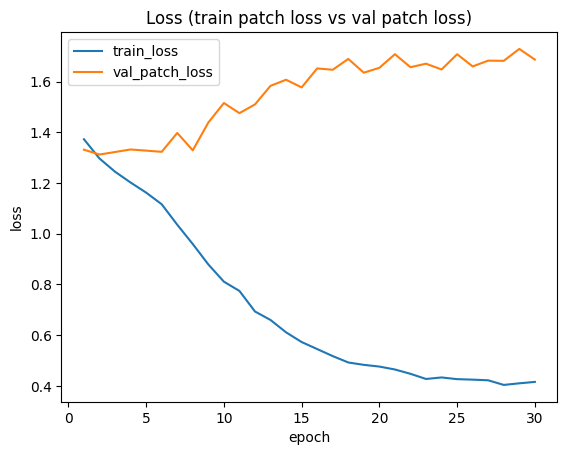

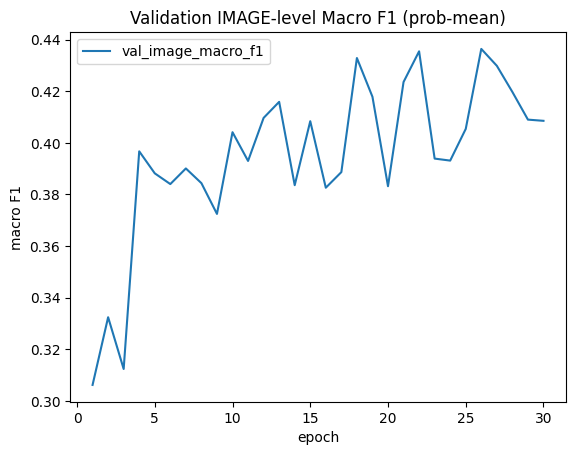

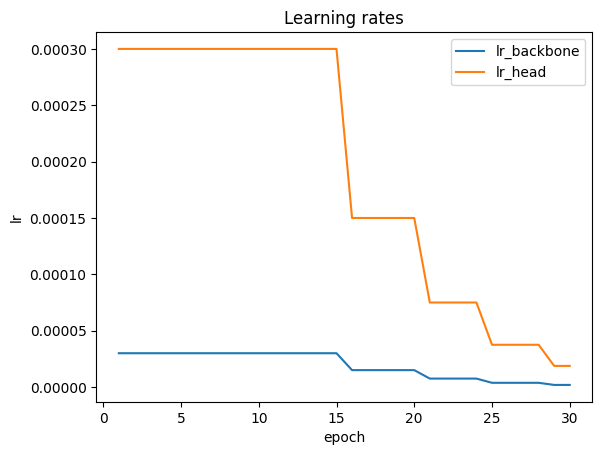

In [ ]:
# No-fold training: patch training + IMAGE-level validation (probability aggregation)
# Regularized head (2048->256->4 + dropout), label smoothing, freeze backbone 5 epochs then unfreeze layer4
# Plots: train loss, val image-F1, val image-loss

# CONFIG
SEED = 42
FREEZE_EPOCHS = 5
EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 2

HEAD_LR = 3e-4
BACKBONE_LR = 3e-5
WEIGHT_DECAY = 1e-4

DROPOUT_P = 0.1
HIDDEN = 256
LABEL_SMOOTHING = 0.05

AUG_P_FLIP = 0.5
AUG_MAX_SHIFT = 8


LABEL2ID = {"HER2(+)": 0, "Luminal A": 1, "Luminal B": 2, "Triple negative": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def encode_labels(y):
    y = np.asarray(y)
    if y.dtype == object or y.dtype.type is np.str_:
        y = np.vectorize(LABEL2ID.get)(y)
    return y.astype(np.int64)

def seed_all(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)


# AUGMENT
class SimpleAug:
    def __init__(self, p_flip=0.5, max_shift=8):
        self.p_flip = p_flip
        self.max_shift = max_shift

    def __call__(self, x):  # x: (C,H,W)
        if torch.rand(1).item() < self.p_flip:
            x = TF.hflip(x)
        if torch.rand(1).item() < self.p_flip:
            x = TF.vflip(x)
        if self.max_shift > 0:
            dx = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
            dy = int(torch.randint(-self.max_shift, self.max_shift + 1, (1,)).item())
            x = TF.affine(
                x, angle=0.0, translate=[dx, dy], scale=1.0, shear=[0.0, 0.0],
                interpolation=TF.InterpolationMode.BILINEAR
            )
        return x


# DATASET (returns patch + label + img_id)
class PatchDataset(Dataset):
    def __init__(self, X, y, img_ids, augment=None):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(encode_labels(y)).long()
        self.img_ids = np.asarray(img_ids)  # keep as numpy (strings ok)
        self.augment = augment

        if self.X.max() > 1.5:  # 0..255 -> 0..1
            self.X = self.X / 255.0

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self): return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3,224,224) in [0,1]
        y = self.y[idx]
        img_id = self.img_ids[idx]

        if self.augment is not None:
            x = self.augment(x)

        x = (x - self.mean) / self.std
        return x, y, img_id


# MODEL: ResNet101 + regularized head
def build_model():
    m = resnet50(weights=ResNet50_Weights.DEFAULT)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, HIDDEN),
        nn.ReLU(inplace=True),
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(HIDDEN, 4),
    )
    return m

def freeze_backbone(model, freeze=True):
    for name, p in model.named_parameters():
        if name.startswith("fc."):
            p.requires_grad = True
        else:
            p.requires_grad = not freeze

def unfreeze_layer4_only(model):
    # keep everything frozen except layer4 + fc
    for name, p in model.named_parameters():
        if name.startswith("fc.") or name.startswith("layer4."):
            p.requires_grad = True
        else:
            p.requires_grad = False

def make_optimizer(model, head_lr, backbone_lr, wd):
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("fc."):
            head_params.append(p)
        else:
            backbone_params.append(p)
    return torch.optim.AdamW(
        [{"params": backbone_params, "lr": backbone_lr},
         {"params": head_params, "lr": head_lr}],
        weight_decay=wd
    )

# IMAGE-LEVEL VALIDATION (mean probability aggregation)
@torch.no_grad()
def eval_image_level(model, loader, device, criterion):
    model.eval()

    # accumulate per-image probability sums and counts
    prob_sum = {}   # img_id -> np.array(4,)
    count = {}      # img_id -> int
    true_label = {} # img_id -> int

    loss_sum, n = 0.0, 0

    for xb, yb, img_id in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        probs = F.softmax(logits, dim=1).detach().cpu().numpy()
        y_cpu = yb.detach().cpu().numpy()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        n += bs

        # img_id is a tuple/list of strings/ints from DataLoader
        for i in range(bs):
            k = img_id[i]
            if k not in prob_sum:
                prob_sum[k] = probs[i].copy()
                count[k] = 1
                true_label[k] = int(y_cpu[i])
            else:
                prob_sum[k] += probs[i]
                count[k] += 1

    # finalize per image
    y_true, y_pred = [], []
    for k in prob_sum.keys():
        mean_probs = prob_sum[k] / count[k]
        pred = int(mean_probs.argmax())
        y_true.append(true_label[k])
        y_pred.append(pred)

    img_macro_f1 = f1_score(y_true, y_pred, average="macro") if len(y_true) else 0.0
    patch_loss = loss_sum / max(n, 1)

    return patch_loss, img_macro_f1, len(y_true)

class EarlyStopF1:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -1.0
        self.bad = 0

    def step(self, f1):
        if f1 > self.best + self.min_delta:
            self.best = f1
            self.bad = 0
            return True
        self.bad += 1
        return False

    @property
    def stop(self):
        return self.bad >= self.patience


# SPLIT BY IMAGE
y_all = encode_labels(y_train_loaded)
img_ids_all = np.asarray(img_indices_train_loaded)

unique_imgs = np.unique(img_ids_all)
train_imgs, val_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=SEED, shuffle=True)

train_mask = np.isin(img_ids_all, train_imgs)
val_mask = np.isin(img_ids_all, val_imgs)

X_tr, y_tr, ids_tr = X_train_loaded[train_mask], y_train_loaded[train_mask], img_ids_all[train_mask]
X_va, y_va, ids_va = X_train_loaded[val_mask],   y_train_loaded[val_mask],   img_ids_all[val_mask]

print("Train patches:", X_tr.shape, "Val patches:", X_va.shape)
print("Train unique images:", len(np.unique(ids_tr)), "Val unique images:", len(np.unique(ids_va)))


# DATALOADERS
aug = SimpleAug(p_flip=AUG_P_FLIP, max_shift=AUG_MAX_SHIFT)
train_ds = PatchDataset(X_tr, y_tr, ids_tr, augment=aug)
val_ds   = PatchDataset(X_va, y_va, ids_va, augment=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)


# LOSS (class weights + label smoothing)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_model().to(device)

ytr_int = torch.from_numpy(encode_labels(y_tr))
counts = np.bincount(ytr_int.numpy(), minlength=4).astype(np.float32)
cw = counts.sum() / (counts + 1e-8)
cw = cw / cw.mean()
class_w = torch.tensor(cw, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=LABEL_SMOOTHING)


# TRAIN LOOP
hist = {"train_loss": [], "val_patch_loss": [], "val_img_f1": [], "lr_head": [], "lr_backbone": []}
early = EarlyStopF1(patience=6)

best_state = None

# freeze backbone for first FREEZE_EPOCHS
freeze_backbone(model, freeze=True)
optimizer = make_optimizer(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, wd=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

for epoch in range(1, EPOCHS + 1):
    # unfreeze at epoch FREEZE_EPOCHS+1 (only layer4 + head)
    if epoch == FREEZE_EPOCHS + 1:
        print(f"\n🔓 Unfreezing layer4 at epoch {epoch} (layer4 + head trainable)")
        unfreeze_layer4_only(model)
        optimizer = make_optimizer(model, head_lr=HEAD_LR, backbone_lr=BACKBONE_LR, wd=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    model.train()
    loss_sum, n = 0.0, 0

    for xb, yb, _ in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        loss_sum += loss.item() * bs
        n += bs

    train_loss = loss_sum / max(n, 1)

    val_patch_loss, val_img_f1, n_val_imgs = eval_image_level(model, val_loader, device, criterion)
    scheduler.step(val_img_f1)

    # track LRs
    lr_backbone = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    hist["train_loss"].append(train_loss)
    hist["val_patch_loss"].append(val_patch_loss)
    hist["val_img_f1"].append(val_img_f1)
    hist["lr_head"].append(lr_head)
    hist["lr_backbone"].append(lr_backbone)

    phase = "FROZEN" if epoch <= FREEZE_EPOCHS else "L4+HEAD"
    print(f"Epoch {epoch:02d}/{EPOCHS} [{phase}] | "
          f"train_loss={train_loss:.4f} | val_patch_loss={val_patch_loss:.4f} | "
          f"val_img_macro_f1={val_img_f1:.4f} (imgs={n_val_imgs}) | "
          f"lr_backbone={lr_backbone:.2e} lr_head={lr_head:.2e}")

    if early.step(val_img_f1):
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print("  ✅ best image-level F1 improved")
    if early.stop:
        print(f"🛑 early stop. best val_img_macro_f1={early.best:.4f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

# save
torch.save(model.state_dict(), "best_resnet50_imageval.pth")
print("✅ Saved best model to best_resnet50_imageval.pth")


# PLOTS
xs = np.arange(1, len(hist["train_loss"]) + 1)

plt.figure()
plt.plot(xs, hist["train_loss"], label="train_loss")
plt.plot(xs, hist["val_patch_loss"], label="val_patch_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss (train patch loss vs val patch loss)")
plt.show()

plt.figure()
plt.plot(xs, hist["val_img_f1"], label="val_image_macro_f1")
plt.xlabel("epoch"); plt.ylabel("macro F1"); plt.legend(); plt.title("Validation IMAGE-level Macro F1 (prob-mean)")
plt.show()

plt.figure()
plt.plot(xs, hist["lr_backbone"], label="lr_backbone")
plt.plot(xs, hist["lr_head"], label="lr_head")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.legend(); plt.title("Learning rates")
plt.show()


###Inferencing Second Model (Resnet50)

In [ ]:
# CONFIG

MODEL_PATH = "best_resnet50_imageval.pth"
OUT_CSV_PATH = "submission.csv"

BATCH_SIZE = 64
NUM_WORKERS = 2

# Optional TTA
USE_TTA = True
TTA_COPIES = 6
MAX_SHIFT = 6

# Head config MUST match training
HIDDEN = 256
DROPOUT_P = 0.1

ID2LABEL = {
    0: "HER2(+)",
    1: "Luminal A",
    2: "Luminal B",
    3: "Triple negative"
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


# Dataset (same normalization as training)
class TestPatchDataset(Dataset):
    def __init__(self, X, img_ids):
        self.X = torch.from_numpy(X).float()
        self.img_ids = np.asarray(img_ids)

        if self.X.max() > 1.5:
            self.X = self.X / 255.0

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        x = (x - self.mean) / self.std
        return x, self.img_ids[idx]


# Build model (must match training head)
def build_model():
    m = resnet50(weights=ResNet50_Weights.DEFAULT)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, HIDDEN),
        nn.ReLU(inplace=True),
        nn.Dropout(p=DROPOUT_P),
        nn.Linear(HIDDEN, 4)
    )
    return m


# TTA helper (flip + small translation)
def tta_batch(x, max_shift=6):
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[3])  # hflip
    if torch.rand(1).item() < 0.5:
        x = torch.flip(x, dims=[2])  # vflip

    if max_shift > 0:
        out = []
        for i in range(x.size(0)):
            dx = int(torch.randint(-max_shift, max_shift + 1, (1,), device=x.device).item())
            dy = int(torch.randint(-max_shift, max_shift + 1, (1,), device=x.device).item())
            out.append(
                TF.affine(
                    x[i],
                    angle=0.0,
                    translate=[dx, dy],
                    scale=1.0,
                    shear=[0.0, 0.0],
                    interpolation=TF.InterpolationMode.BILINEAR
                )
            )
        x = torch.stack(out, dim=0)
    return x

@torch.no_grad()
def infer_patch_probs(model, loader, use_tta=False, tta_copies=6, max_shift=6):
    """
    Returns: dict(img_id -> sum_probs(4,), count)
    """
    model.eval()
    prob_sum = {}
    count = {}

    for xb, img_id in loader:
        xb = xb.to(device, non_blocking=True)

        if not use_tta:
            probs = F.softmax(model(xb), dim=1)
        else:
            probs_sum = F.softmax(model(xb), dim=1)
            for _ in range(tta_copies):
                xb_aug = tta_batch(xb, max_shift=max_shift)
                probs_sum += F.softmax(model(xb_aug), dim=1)
            probs = probs_sum / (1 + tta_copies)

        probs = probs.detach().cpu().numpy()

        # img_id is a list/array of strings
        for i in range(len(img_id)):
            k = img_id[i]
            if k not in prob_sum:
                prob_sum[k] = probs[i].copy()
                count[k] = 1
            else:
                prob_sum[k] += probs[i]
                count[k] += 1

    return prob_sum, count


# Load test data from directory
# Initialize empty lists
X_test = []
img_indices = []

# Directory containing image tiles
test_tile_dir = "/content/test_tiles_filtered"
image_size = (224, 224) # Target size for resizing

# Iterate through all files in the directory
all_test_files = os.listdir(test_tile_dir)
image_test_tile_files = [f for f in all_test_files if f.startswith('img_') and f.endswith('.png') and 'mask' not in f]

print(f"Found {len(image_test_tile_files)} test image tiles to process.")

# Use tqdm for a progress bar
for filename in tqdm(image_test_tile_files, desc="Processing test image tiles"):
    filepath = os.path.join(test_tile_dir, filename)

    # Extract the main image ID (e.g., img_XXXX) from the tile filename
    match = re.match(r"^(img_\d{4})_tile_\d{2}\.png$", filename)
    if match:
        main_image_id = match.group(1)

        # Load the image tile, resize, convert to NumPy array, and transpose
        try:
            img = Image.open(filepath).convert('RGB')
            if img.size != image_size:
                img = img.resize(image_size)

            img_array = np.array(img, dtype=np.uint8) # Keep as uint8 for now, normalize later in Dataset
            img_array = img_array.transpose(2, 0, 1) # Convert to (channels, height, width)

            # Append the processed image array and the main image ID
            X_test.append(img_array)
            img_indices.append(main_image_id)
        except Exception as e:
            print(f"Error processing {filename}: {e}")
    else:
        pass # Skip files that don't match the tile pattern

# Convert these lists into NumPy arrays
X_test = np.array(X_test)
img_indices = np.array(img_indices)

print(f"\nFinished loading test data.")
print(f"X_test shape: {X_test.shape}")
print(f"img_indices shape: {img_indices.shape}")

ds = TestPatchDataset(X_test, img_indices)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)


# Load model weights
model = build_model()
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.to(device).eval()
print(f"✅ Loaded model: {MODEL_PATH}")


# Patch -> image probability mean
prob_sum, count = infer_patch_probs(
    model, loader,
    use_tta=USE_TTA,
    tta_copies=TTA_COPIES,
    max_shift=MAX_SHIFT
)

rows = []
for img_id in prob_sum.keys():
    mean_probs = prob_sum[img_id] / count[img_id]
    pred = int(mean_probs.argmax())
    rows.append({"sample_index": str(img_id)+".png", "label": ID2LABEL[pred]})

df = pd.DataFrame(rows).sort_values("sample_index").reset_index(drop=True)
df.to_csv(OUT_CSV_PATH, index=False)

print("✅ Saved CSV:", OUT_CSV_PATH)
df.head(10)


Device: cuda
Found 2063 test image tiles to process.


Processing test image tiles:   0%|          | 0/2063 [00:00<?, ?it/s]


Finished loading test data.
X_test shape: (2063, 3, 224, 224)
img_indices shape: (2063,)
✅ Loaded model: best_resnet50_imageval.pth
✅ Saved CSV: submission.csv


,sample_index,label
0,img_0000.png,Luminal B
1,img_0001.png,Luminal A
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal A
5,img_0005.png,Luminal B
6,img_0006.png,Triple negative
7,img_0007.png,Luminal B
8,img_0008.png,HER2(+)
9,img_0009.png,Luminal A


###Ensemble

In [ ]:
# we used this code for hard-voting the submission files, but we did not select their result for the leaderboard (we selected our model submission files)

import pandas as pd
from pathlib import Path

FILES = [
    "/content/drive/MyDrive/preds (2).csv",
    "/content/drive/MyDrive/submission09.csv",
    "/content/drive/MyDrive/test_predictions_probmean (5).csv",
    "/content/drive/MyDrive/test_predictions_probmean.csv",
    "/content/drive/MyDrive/preds.csv",
    "/content/drive/MyDrive/test_predictions_kfold_ensemble_probmean (1).csv",
]
OUT_FILE = "hard_vote_ensemble.csv"


def read_pred_csv(path: str) -> pd.DataFrame:
    """Reads a CSV with columns sample_index + label.
    Also handles the case where the CSV accidentally has a first header row like 'Standard,Standard'
    and the real column names appear as the first data row.
    """
    df = pd.read_csv(path)

    if (
        "sample_index" not in [c.lower() for c in df.columns]
        and len(df.columns) == 2
        and all(str(c).lower().startswith("standard") for c in df.columns)
    ):
        new_cols = [str(x).strip() for x in df.iloc[0].tolist()]
        df = df.iloc[1:].reset_index(drop=True)
        df.columns = new_cols

    # Normalize column names
    cols = {c.lower(): c for c in df.columns}
    if "sample_index" not in cols or "label" not in cols:
        raise ValueError(f"{path}: expected columns sample_index & label, got {list(df.columns)}")

    out = df[[cols["sample_index"], cols["label"]]].copy()
    out.columns = ["sample_index", Path(path).stem]  # rename label column to file stem
    return out


def hard_vote_row(row: pd.Series):
    counts = row.value_counts(dropna=False)
    top = counts.max()
    winners = list(counts[counts == top].index)

    # tie-breaker: pick the label from the first model (stable & common)
    return winners[0] if len(winners) == 1 else row.iloc[0]


# ---- main ----
dfs = [read_pred_csv(f) for f in FILES]

merged = dfs[0]
for d in dfs[1:]:
    merged = merged.merge(d, on="sample_index", how="inner", validate="one_to_one")

vote_cols = [c for c in merged.columns if c != "sample_index"]
merged["label"] = merged[vote_cols].apply(hard_vote_row, axis=1)

merged[["sample_index", "label"]].to_csv(OUT_FILE, index=False)
print(f"Saved {OUT_FILE} with {len(merged)} rows")
